In [1]:
# Optional setup cell.
# Keep commented for final delivery and reproducibility via requirements files.
# %pip install -U pip scipy kagglehub pandas matplotlib geopandas scikit-learn umap-learn neo4j networkx seaborn

In [2]:
# Import libs

import pandas as pd
import numpy as np
import datetime
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import geopandas as gpd
import seaborn as sns
from scipy.stats import entropy
from sklearn.preprocessing import OneHotEncoder
import os
from statlib.domain_tools import load_datasets
from copy import copy, deepcopy
from statlib.representative_sample import find_most_representative_sample, generic_df_into_numeric_and_rollback
import tempfile
from pathlib import Path
import requests
import zipfile
import networkx as nx
from scipy.stats import ks_2samp
from networkx.algorithms.community import greedy_modularity_communities, girvan_newman, modularity
from networkx.algorithms.community import modularity, louvain_communities
from sklearn.preprocessing import  StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform


In [3]:
# Datasets loading
ds_name_list = ["airlines.csv","airports.csv","flights.csv"]
df_full = load_datasets(ds_name_list, omogenize=True)

/media/simone/USB_projects/Usefull/ATTIVI/Esericizi/Big_data/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading airlines.csv...
Loading airports.csv...
Loading flights.csv...


/media/simone/USB_projects/Usefull/ATTIVI/Esericizi/Big_data/venv/lib/python3.13/site-packages/kagglehub/pandas_datasets.py:92: DtypeWarning: Columns (0: ORIGIN_AIRPORT, 1: DESTINATION_AIRPORT) have mixed types. Specify dtype option on import or set low_memory=False.
  result = read_function(


In [4]:

# split data type

flights_column_type = {
    # numeric
    "YEAR": "Val",
    "MONTH": "Val",
    "DAY": "Val",
    "DAY_OF_WEEK": "Val",
    "FLIGHT_NUMBER": "Val",
    "SCHEDULED_DEPARTURE": "Val",
    "DEPARTURE_TIME": "Val",
    "DEPARTURE_DELAY": "Val",
    "TAXI_OUT": "Val",
    "WHEELS_OFF": "Val",
    "SCHEDULED_TIME": "Val",
    "ELAPSED_TIME": "Val",
    "AIR_TIME": "Val",
    "DISTANCE": "Val",
    "WHEELS_ON": "Val",
    "TAXI_IN": "Val",
    "SCHEDULED_ARRIVAL": "Val",
    # number
    "CANCELLATION_REASON": "Str",
    "AIRLINE": "Str",
    "TAIL_NUMBER": "Str",
    "ORIGIN_AIRPORT": "Str",
    "DESTINATION_AIRPORT": "Str",
}

In [5]:
# Set global parameters 
FAST_SAMPLE = True
GLOBAL_SEED = 667
SAMPLE_SIZE = 5000
CACHE_FILE = "sample_cache"

In [6]:

# make a copy for future analisys
dfs_kv = copy(df_full)
if FAST_SAMPLE:
    for k in dfs_kv.keys():
        filename=CACHE_FILE+k+'.csv'
        filename_pkl=CACHE_FILE+k+'.pkl'
        if len(df_full[k]) > SAMPLE_SIZE:
            if os.path.exists(filename):
                dfs_kv[k] = pd.read_csv(filename)
            else:
                try:
                    dfs_kv[k] = pd.read_pickle(filename_pkl)
                    dfs_kv[k].to_csv(filename, index=False)
                except :
                    dfs_kv[k] = find_most_representative_sample(dfs_kv[k] , flights_column_type, GLOBAL_SEED , SAMPLE_SIZE, n_trials=35  )
                    dfs_kv[k].to_pickle(filename_pkl)

# Dataset description

- flights.csv
    - YEAR, MONTH, DAY, DAY_OF_WEEK: dates of the flight
    - AIRLINE: identify a unique airline
    - ORIGIN_AIRPORT_IATA_CODE and DESTINATION_AIRPORT_IATA_CODE: code attributed by IATA to identify the airports
    - SCHEDULED_DEPARTURE and SCHEDULED_ARRIVAL : scheduled times of take-off and landing
    - DEPARTURE_TIME and ARRIVAL_TIME: real times at which take-off and landing took place
    - DEPARTURE_DELAY and ARRIVAL_DELAY: difference (in minutes) between planned and real times
    - DISTANCE: distance (in miles)
    - CANCELLED: 1 if is deleted
    - CANCELLATION_REASON: if is cancelled, the reason code
    - SCHEDULED_TIME: estimated flight time
    - ELAPSED_TIME: effective flight time
    - AIR_TIME: effective on-air time
    - TAXI_OUT: time from the gate to lift-off
    - WHEELS_OFF: effective moment of lift-off
    - WHEELS_ON: effective moment of landing
    - DIVERTED: some reason flight get different landing
- airports.csv
    - AIRPORTS_IATA_CODE: unique identifier code
    - CITY STATE COUNTRY LATITUDE LONGITUDE : geo referencies
- airlines.csv
    . naming referencies (we can ignore it for data analisys)


In [7]:
# dataset preview
for df in dfs_kv.values():
    display(df.head())

,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways


,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,6,28,7,DL,2241,N3762Y,ATL,ORD,2048,...,2147.0,-10.0,False,False,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,7,24,5,B6,50,N316JB,SAV,BOS,1415,...,1629.0,-4.0,False,False,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,8,8,6,OO,6354,N908SW,DEN,FCA,1414,...,1607.0,-21.0,False,False,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,12,23,3,B6,52,N637JB,MCO,BOS,805,...,1100.0,7.0,False,False,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,11,8,7,UA,898,N835UA,IAH,MSY,2127,...,2225.0,-15.0,False,False,NaN,NaN,NaN,NaN,NaN,NaN


# Taking a look on Airport geographical displacement

In [8]:
# plot geo data


tmpdir = Path(tempfile.mkdtemp(prefix="us_maps_"))
url = "https://www2.census.gov/geo/tiger/GENZ2025/shp/cb_2025_us_state_5m.zip"
r = requests.get(url, stream=True)
r.raise_for_status()
zip_path = tmpdir / "us_states.zip"
with open(zip_path, "wb") as f:
    for chunk in r.iter_content(chunk_size=8192):
        f.write(chunk)

In [9]:
# write geo shapefile

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(tmpdir)


In [10]:
# read geo shapefile and airports data, creating a geodataframe for both

shp_files = list(tmpdir.glob("*.shp"))
states_gdf = gpd.read_file(shp_files[0])
airports_gdf = gpd.GeoDataFrame(
    dfs_kv["airports.csv"],
    geometry=gpd.points_from_xy(
        dfs_kv["airports.csv"]["LONGITUDE"], 
        dfs_kv["airports.csv"]["LATITUDE"]
    ),
    crs="EPSG:4326"  # WGS84
)


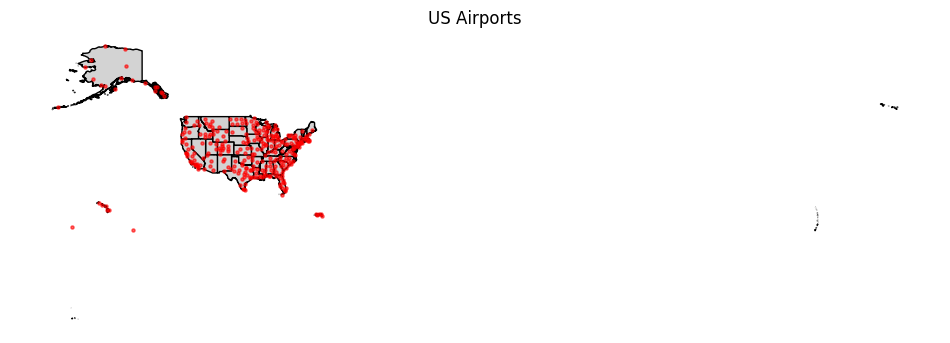

In [11]:
# Plot: states + airports
fig, ax = plt.subplots(figsize=(12, 8))

# Plot states
states_gdf.plot(ax=ax, color="lightgray", edgecolor="black")

# Plot airports
airports_gdf.plot(ax=ax, color="red", markersize=5, alpha=0.6)

ax.set_title("US Airports")
ax.set_axis_off()
plt.show()

In [12]:
# usefull functions
def pick_col(df: pd.DataFrame, candidates: list[str], required: bool = True) -> str | None:
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"Missing required column. Tried: {candidates}")
    return None

def format_hhmm(value: int | float | str):
    if pd.isna(value):
        return pd.NA
    try:
        value = int(value)
    except Exception:
        return pd.NA
    if value == 2400:
        value = 0
    if value < 0 or value > 2359:
        return pd.NA
    s = f"{value:04d}"
    hh, mm = int(s[:2]), int(s[2:])
    if hh > 23 or mm > 59:
        return pd.NA
    return datetime.time(hh, mm)

def total_delay(row):
    arr = row.get("ARRIVAL_DELAY", np.nan)
    dep = row.get("DEPARTURE_DELAY", np.nan)
    arr = arr if pd.notna(arr) and arr > 0 else 0
    dep = dep if pd.notna(dep) and dep > 0 else 0
    cancel_reason = row.get("CANCELLATION_REASON", pd.NA)
    if pd.isna(cancel_reason) or cancel_reason == "":
        return (arr + dep)/2 # equal divided by starting and arrival
    return pd.NA

def max_delay_if_cancelled(row, max_delay_value):
    if bool(row.get("DIVERTED", False)):
        return max_delay_value
    cancel_reason = row.get("CANCELLATION_REASON", pd.NA)
    if pd.isna(cancel_reason) or cancel_reason == "":
        return row.get("TOTAL_DELAY", pd.NA)
    return max_delay_value

In [13]:
# Canonical column aliases to support small naming differences across datasets
COLUMN_ALIASES = {
    "AIRLINE": ["AIRLINE", "AIRLINES_IATA_CODE"],
    "ORIGIN_IATA": ["ORIGIN_AIRPORT_IATA_CODE", "ORIGIN_AIRPORT"],
    "DEST_IATA": ["DESTINATION_AIRPORT_IATA_CODE", "DESTINATION_AIRPORT"],
}

In [14]:
# Cancellation short description
BTS_MAP_CANCELLATION_REASON = {
    "A": "Carrier",
    "B": "Weather",
    "C": "National Air System",
    "D": "Late Aircraft",
}

In [15]:
# create working copies
flights_raw = deepcopy(dfs_kv["flights.csv"])
airports_raw = deepcopy(dfs_kv["airports.csv"])

AIRLINE_COL = pick_col(flights_raw, COLUMN_ALIASES["AIRLINE"])
ORIGIN_COL = pick_col(flights_raw, COLUMN_ALIASES["ORIGIN_IATA"])
DEST_COL = pick_col(flights_raw, COLUMN_ALIASES["DEST_IATA"])

In [16]:
# numeric similar to EDA notebook
for c in ["ARRIVAL_DELAY", "DEPARTURE_DELAY"]:
    if c in flights_raw.columns:
        flights_raw[c] = pd.to_numeric(flights_raw[c], errors="coerce")

In [17]:
# Date merging
date_parts = ["YEAR", "MONTH", "DAY"]
if all(c in flights_raw.columns for c in date_parts):
    flights_raw["DATETIME"] = pd.to_datetime(flights_raw[date_parts], errors="coerce")

In [18]:
# Core categorical casts for flights data
if "CANCELLED" in flights_raw.columns:
    flights_raw["CANCELLED"] = flights_raw["CANCELLED"].astype(bool)
for c in [AIRLINE_COL, ORIGIN_COL, DEST_COL, "CANCELLATION_REASON"]:
    if c in flights_raw.columns:
        flights_raw[c] = flights_raw[c].astype("category")

In [19]:
# Cast airport metadata columns to categorical type for compact storage.
for c in ["CITY", "STATE", "COUNTRY", "AIRPORTS_IATA_CODE"]:
    if c in airports_raw.columns:
        airports_raw[c] = airports_raw[c].astype("category")

In [20]:


# HHMM -> time conversion 
for c in ["SCHEDULED_DEPARTURE", "DEPARTURE_TIME", "SCHEDULED_ARRIVAL", "ARRIVAL_TIME"]:
    if c in flights_raw.columns:
        flights_raw[c] = flights_raw[c].apply(format_hhmm)

In [21]:
# 2) Standardize codes and merge airport geo fields for origin/destination
flights_df = flights_raw.copy()
flights_df[ORIGIN_COL] = flights_df[ORIGIN_COL].astype(str).str.strip().str.upper()
flights_df[DEST_COL] = flights_df[DEST_COL].astype(str).str.strip().str.upper()

AIRPORT_CODE_COL = pick_col(airports_raw, ["AIRPORTS_IATA_CODE", "IATA_CODE"])

origin_airports = airports_raw.rename(columns={
    AIRPORT_CODE_COL: "ORIGIN_AIRPORTS_IATA_CODE",
    "CITY": "ORIGIN_CITY",
    "STATE": "ORIGIN_STATE",
    "COUNTRY": "ORIGIN_COUNTRY",
    "LATITUDE": "ORIGIN_LATITUDE",
    "LONGITUDE": "ORIGIN_LONGITUDE",
}).copy()
origin_airports["ORIGIN_AIRPORTS_IATA_CODE"] = origin_airports["ORIGIN_AIRPORTS_IATA_CODE"].astype(str).str.strip().str.upper()


In [22]:
# Rename the destination airport fields to a distinct prefix before merging.

dest_airports = airports_raw.rename(columns={
    AIRPORT_CODE_COL: "DEST_AIRPORTS_IATA_CODE",
    "CITY": "DEST_CITY",
    "STATE": "DEST_STATE",
    "COUNTRY": "DEST_COUNTRY",
    "LATITUDE": "DEST_LATITUDE",
    "LONGITUDE": "DEST_LONGITUDE",
}).copy()
dest_airports["DEST_AIRPORTS_IATA_CODE"] = dest_airports["DEST_AIRPORTS_IATA_CODE"].astype(str).str.strip().str.upper()


In [23]:
# merge flight rows with origin airport 
df = pd.merge(
    flights_df,
    origin_airports,
    left_on=ORIGIN_COL,
    right_on="ORIGIN_AIRPORTS_IATA_CODE",
    how="left",
)

In [24]:
# Memrge the destination airport 

df = pd.merge(
    df,
    dest_airports,
    left_on=DEST_COL,
    right_on="DEST_AIRPORTS_IATA_CODE",
    how="left",
)

In [25]:
# Compute total delay and apply the cancellation/diversion policy.

df["TOTAL_DELAY"] = df.apply(total_delay, axis=1)
max_delay = pd.to_numeric(df["TOTAL_DELAY"], errors="coerce").max()
df["TOTAL_DELAY"] = df.apply(max_delay_if_cancelled, axis=1, max_delay_value=max_delay)

In [26]:
# Drop other kind of delay
to_drop = [
  "AIRLINE_DELAY",
  "LATE_AIRCRAFT_DELAY",
  "AIR_SYSTEM_DELAY",
  "WEATHER_DELAY",
  "SECURITY_DELAY",
]

for i in to_drop:
    df.drop(columns=i, inplace=True)

In [27]:
# Keep a Neo4j-oriented subset 
neo_fields = [
    "DATETIME",
    AIRLINE_COL,
    ORIGIN_COL,
    DEST_COL,
    "ORIGIN_AIRPORTS_IATA_CODE",
    "ORIGIN_CITY",
    "ORIGIN_STATE",
    "ORIGIN_LATITUDE",
    "ORIGIN_LONGITUDE",
    "DEST_AIRPORTS_IATA_CODE",
    "DEST_CITY",
    "DEST_STATE",
    "DEST_LATITUDE",
    "DEST_LONGITUDE",
    "DISTANCE",
    "CANCELLATION_REASON",
    "TOTAL_DELAY",
]
neo_fields = [c for c in neo_fields if c in df.columns]
df_base_final = df[neo_fields].copy()

# Normalize cancellation reason labels 
if "CANCELLATION_REASON" in df_base_final.columns:
    cr = df_base_final["CANCELLATION_REASON"].astype("string")
    df_base_final["CANCELLATION_REASON"] = cr.map(BTS_MAP_CANCELLATION_REASON).fillna(cr)

df_base_final.head()

,DATETIME,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,ORIGIN_AIRPORTS_IATA_CODE,ORIGIN_CITY,ORIGIN_STATE,ORIGIN_LATITUDE,ORIGIN_LONGITUDE,DEST_AIRPORTS_IATA_CODE,DEST_CITY,DEST_STATE,DEST_LATITUDE,DEST_LONGITUDE,DISTANCE,CANCELLATION_REASON,TOTAL_DELAY
0,2015-06-28,DL,ATL,ORD,ATL,Atlanta,GA,33.64044,-84.42694,ORD,Chicago,IL,41.97960,-87.90446,606,NaN,0.5
1,2015-07-24,B6,SAV,BOS,SAV,Savannah,GA,32.12758,-81.20214,BOS,Boston,MA,42.36435,-71.00518,901,NaN,0.0
2,2015-08-08,OO,DEN,FCA,DEN,Denver,CO,39.85841,-104.66700,FCA,Kalispell,MT,48.31140,-114.25507,752,NaN,0.0
3,2015-12-23,B6,MCO,BOS,MCO,Orlando,FL,28.42889,-81.31603,BOS,Boston,MA,42.36435,-71.00518,1121,NaN,10.5
4,2015-11-08,UA,IAH,MSY,IAH,Houston,TX,29.98047,-95.33972,MSY,New Orleans,LA,29.99339,-90.25803,305,NaN,0.0


In [28]:
# Apply the same final null policy used in the report
nullable_cols = {"CANCELLATION_REASON"}
colums = set(df_base_final.columns)
not_nullable_cols = colums - nullable_cols
#not_nullable_cols = [c for c in df_base_final.columns if c not in nullable_cols]

In [29]:
# Print intermediate dataset shape
rows_before = len(df_base_final)
df_final_clean = df_base_final.dropna(subset=not_nullable_cols).copy()
rows_after = len(df_final_clean)
print(f"Rows before clean: {rows_before}")
print(f"Rows after clean : {rows_after}")

Rows before clean: 5000
Rows after clean : 4522


In [30]:
# Build a missing-values report before and after cleaning.
df_final_fill_report = pd.DataFrame({
    "column": df_base_final.columns,
    "missing_before": [int(df_base_final[c].isna().sum()) for c in df_base_final.columns],
    "missing_after": [int(df_final_clean[c].isna().sum()) for c in df_base_final.columns],
}).sort_values("missing_before", ascending=False).reset_index(drop=True)

display(df_final_fill_report.head())

,column,missing_before,missing_after
0,CANCELLATION_REASON,4935,4461
1,ORIGIN_LONGITUDE,474,0
2,ORIGIN_LATITUDE,474,0
3,DEST_LONGITUDE,472,0
4,DEST_LATITUDE,472,0


In [31]:
# Prepare node and relationship tables for Neo4j ingestion
df_final_clean = df_final_clean.reset_index(drop=True)
df_final_clean["FLIGHT_ID"] = np.arange(1, len(df_final_clean) + 1)

origin_nodes = df_final_clean[[
    "ORIGIN_AIRPORTS_IATA_CODE",
    "ORIGIN_CITY",
    "ORIGIN_STATE",
    "ORIGIN_LATITUDE",
    "ORIGIN_LONGITUDE",
]].rename(columns={
    "ORIGIN_AIRPORTS_IATA_CODE": "IATA",
    "ORIGIN_CITY": "CITY",
    "ORIGIN_STATE": "STATE",
    "ORIGIN_LATITUDE": "LATITUDE",
    "ORIGIN_LONGITUDE": "LONGITUDE",
})

dest_nodes = df_final_clean[[
    "DEST_AIRPORTS_IATA_CODE",
    "DEST_CITY",
    "DEST_STATE",
    "DEST_LATITUDE",
    "DEST_LONGITUDE",
]].rename(columns={
    "DEST_AIRPORTS_IATA_CODE": "IATA",
    "DEST_CITY": "CITY",
    "DEST_STATE": "STATE",
    "DEST_LATITUDE": "LATITUDE",
    "DEST_LONGITUDE": "LONGITUDE",
})

neo_airports = pd.concat([origin_nodes, dest_nodes], ignore_index=True).drop_duplicates(subset=["IATA"])
print(f"Neo4j airports: {neo_airports.shape}")


Neo4j airports: (277, 5)


In [32]:
# Build the final flight table used for Neo4j ingestion.
neo_flights = df_final_clean[[
    "FLIGHT_ID",
    "DATETIME",
    AIRLINE_COL,
    "ORIGIN_AIRPORTS_IATA_CODE",
    "DEST_AIRPORTS_IATA_CODE",
    "DISTANCE",
    "TOTAL_DELAY",
    "CANCELLATION_REASON",
]].rename(columns={
    AIRLINE_COL: "AIRLINE_CODE",
    "ORIGIN_AIRPORTS_IATA_CODE": "ORIGIN_IATA",
    "DEST_AIRPORTS_IATA_CODE": "DEST_IATA",
})

print(f"Neo4j flights: {neo_flights.shape}")

Neo4j flights: (4522, 8)


In [33]:
# saving intermediate csv
export_dir = "neo4j_ready"

file_key_to_filename = {
    "airports_nodes": "airports_nodes.csv",
    "flights_rels": "flights_rels.csv",
    "preprocess_fill_report": "preprocess_fill_report.csv",
}
os.makedirs(export_dir, exist_ok=True)

for key, filename in file_key_to_filename.items():
    file_path = os.path.join(export_dir, filename)
    if os.path.exists(file_path):
        print(f"File already exists, skipping export: {file_path}")
    else:
        if key == "airports_nodes":
            neo_airports.to_csv(file_path, index=False)
        elif key == "flights_rels":
            neo_flights.to_csv(file_path, index=False)
        elif key == "preprocess_fill_report":
            df_final_fill_report.to_csv(file_path, index=False)
        print(f"Exported: {file_path}")

File already exists, skipping export: neo4j_ready/airports_nodes.csv
File already exists, skipping export: neo4j_ready/flights_rels.csv
File already exists, skipping export: neo4j_ready/preprocess_fill_report.csv


In [34]:
# Quick preview airports
display(neo_airports.head())

,IATA,CITY,STATE,LATITUDE,LONGITUDE
0,ATL,Atlanta,GA,33.64044,-84.42694
1,SAV,Savannah,GA,32.12758,-81.20214
2,DEN,Denver,CO,39.85841,-104.66700
3,MCO,Orlando,FL,28.42889,-81.31603
4,IAH,Houston,TX,29.98047,-95.33972


In [35]:
# Quick preview flights
display(neo_flights.head())

,FLIGHT_ID,DATETIME,AIRLINE_CODE,ORIGIN_IATA,DEST_IATA,DISTANCE,TOTAL_DELAY,CANCELLATION_REASON
0,1,2015-06-28,DL,ATL,ORD,606,0.5,NaN
1,2,2015-07-24,B6,SAV,BOS,901,0.0,NaN
2,3,2015-08-08,OO,DEN,FCA,752,0.0,NaN
3,4,2015-12-23,B6,MCO,BOS,1121,10.5,NaN
4,5,2015-11-08,UA,IAH,MSY,305,0.0,NaN


In [36]:
# null value permitted, arrivals
print("permitted null values (not cancelled flights)", neo_flights["CANCELLATION_REASON"].isna().sum())

permitted null values (not cancelled flights) 4461


In [37]:
# dataset len
print("Rows count:", len(df_final_clean))

Rows count: 4522


# End of preprocessing

# Connect and delete GDB
For having an idempotent effect

In [38]:
# Open the Neo4j driver and prepare the query helper functions.
import pandas as pd
from neo4j import GraphDatabase

# Neo4j connection settings
NEO4J_URI      = 'neo4j://debianmagiinferencecpu.local.lan' 
NEO4J_USER = "test"
NEO4J_PASSWORD = "password"
DATABASE = "neo4j"

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))
driver.verify_connectivity()
print("Connected to Neo4j")

Connected to Neo4j


In [39]:
# add query functions toolset
def gen_query (cypher: str, params: dict | None = None, to_df: bool = False):
    with driver.session(database=DATABASE) as session:
        result = session.run(cypher, params or {})
        if to_df:
            return pd.DataFrame([record.data() for record in result])
        else:
            return [record.data() for record in result]

def run_query(cypher: str, params: dict | None = None):
    return gen_query(cypher, params, to_df=False)

def run_query_df(cypher: str, params: dict | None = None) -> pd.DataFrame:
    return gen_query(cypher, params, to_df=True)

In [40]:
# Delete the existing graph (all nodes and relationships)
run_query("MATCH (n) DETACH DELETE n")

[]


## **BASIC GRAPH DEFINITIONS:**

* Undirected vs. Directed
* Cyclic vs. Acyclic
* Weighted vs. Unweighted
* Sparse vs. Dense

---

**Definition (Graph):**
$$
G=(V,E)
$$

where:

* $V$ = set of vertices
* $E$ = multi-set of pairs of vertices

Interpretation:

* Vertices and edges can be univocally identified.
* Maximum number of edges is $|V|^2$; complete graph when every pair is connected.

Example:

* Weighted graph: $W: E \longrightarrow \mathbb{R}$ associates costs, lengths, or capacities to edges.



# Choosing the graph schema

## US Domestic Flights Network


### Node Labels

| Label | Primary Key | Key Properties | Description |
|-------|-------------|----------------|-------------|
| `Airport` | `iata` | `city`, `state`, `latitude`, `longitude` | A physical airport identified by its IATA code. Acts as a stable geographic entity. |
| `Airline` | `code` | - | An airline company identified by its IATA carrier code (e.g. `DL`, `UA`). |
| `Flight` | `flight_id` | `date`, `distance`, `total_delay`, `cancellation_reason` | A single flight event. |
| `Route` | `sourc_iata`,`dest_iata` | `flight_count`,`sum_of_delay` | A route between 2 airports |



In [41]:
# Neo4j Community Edition

constraint = [
    # Unique constraints
    "CREATE CONSTRAINT airport_iata IF NOT EXISTS FOR (a:Airport) REQUIRE a.iata IS UNIQUE;",
    "CREATE CONSTRAINT airline_code IF NOT EXISTS FOR (al:Airline) REQUIRE al.code IS UNIQUE;",
    "CREATE CONSTRAINT flight_id IF NOT EXISTS FOR (f:Flight) REQUIRE f.flight_id IS UNIQUE;",
    #"CREATE CONSTRAINT route_key IF NOT EXISTS FOR (r:Route) REQUIRE (r.source_iata, r.dest_iata) IS NODE KEY;",
    
    "CREATE CONSTRAINT route_id_unique IF NOT EXISTS FOR (r:Route) REQUIRE r.route_id IS UNIQUE;",
    
    # Indexes for performance
    "CREATE INDEX airport_city_idx IF NOT EXISTS FOR (a:Airport) ON (a.city);",
    "CREATE INDEX airport_state_idx IF NOT EXISTS FOR (a:Airport) ON (a.state);",
    "CREATE INDEX flight_date_idx IF NOT EXISTS FOR (f:Flight) ON (f.date);",
    "CREATE INDEX route_source_idx IF NOT EXISTS FOR (r:Route) ON (r.source_iata);",
    "CREATE INDEX route_dest_idx IF NOT EXISTS FOR (r:Route) ON (r.dest_iata);",
    "CREATE INDEX route_flight_count_idx IF NOT EXISTS FOR (r:Route) ON (r.flight_count);",
]

for i in constraint:
    run_query(i)

print("Constraints created.")

Constraints created.


# Airports insertion

In [42]:

rows_airports = neo_airports.to_dict("records")

run_query(
    """
    UNWIND $rows AS row
    MERGE (a:Airport {iata: row.IATA})
    SET a.city = row.CITY,
        a.state = row.STATE,
        a.latitude = row.LATITUDE,
        a.longitude = row.LONGITUDE
    """,
    {"rows": rows_airports},
)

print(f"Inserted airports: {len(rows_airports)}")

Inserted airports: 277


# Flight insertion

- Set all flight properties
```
SET f.date = date(row.DATETIME),  
    f.distance = row.DISTANCE,
    f.total_delay = row.TOTAL_DELAY,
    f.cancellation_reason = CASE WHEN row.CANCELLATION_REASON = "" THEN null ELSE row.CANCELLATION_REASON END
```
- Get or create the OPERATED relationship between airline (al) and flight (f)
```
MERGE (al)-[op:OPERATED]->(f)
```

- If the relationship is newly created, set cancelled_count to 1 if cancelled, otherwise 0
- or If the relationship already exists, increment cancelled_count by 1 if this flight is cancelled

```
ON CREATE SET op.cancelled_count = CASE WHEN coalesce(row.CANCELLED, false) THEN 1 ELSE 0 END
ON MATCH SET op.cancelled_count = op.cancelled_count + (CASE WHEN coalesce(row.CANCELLED, false) THEN 1 ELSE 0 END)
```

- Get or create the FROM relationship between flight and origin airport
```
MERGE (f)-[rf:FROM]->(o)
```


- For new FROM relationships, initialize starting_count to 1 (first flight from this airport)
```
ON CREATE SET rf.starting_count = 1
```

- For existing FROM relationships, increment the counter by 1
```
ON MATCH SET rf.starting_count = rf.starting_count + 1
```

- Get or create the TO relationship between flight and destination airport
```
MERGE (f)-[rt:TO]->(d)
```

- For new TO relationships, initialize arrival_count to 1 (first flight to this airport)
```
ON CREATE SET rt.arrival_count = 1
```

- For existing TO relationships, increment the counter by 1
```
ON MATCH SET rt.arrival_count = rt.arrival_count + 1
```


In [43]:
rows_flights = neo_flights.copy()
rows_flights["DATETIME"] = rows_flights["DATETIME"].astype(str)
rows_flights = rows_flights.to_dict("records")
run_query(
    """
    UNWIND $rows AS row
    MATCH (o:Airport {iata: row.ORIGIN_IATA})
    MATCH (d:Airport {iata: row.DEST_IATA})
    MERGE (al:Airline {code: row.AIRLINE_CODE})
    MERGE (f:Flight {flight_id: row.FLIGHT_ID})

    MERGE (r:Route {route_id: row.ORIGIN_IATA + ' → ' + row.DEST_IATA})
        ON CREATE SET 
            r.source_iata = row.ORIGIN_IATA,
            r.dest_iata = row.DEST_IATA,
            r.flight_count = 1,
            r.sum_of_delay = coalesce(row.TOTAL_DELAY, 0),
            r.last_time_used = date(row.DATETIME)
        ON MATCH SET 
            r.flight_count = r.flight_count + 1,
            r.sum_of_delay = r.sum_of_delay + coalesce(row.TOTAL_DELAY, 0),
            r.last_time_used = date(row.DATETIME)


    SET f.date = date(row.DATETIME),  
        f.distance = row.DISTANCE,
        f.total_delay = row.TOTAL_DELAY,
        f.cancellation_reason = CASE WHEN row.CANCELLATION_REASON = "" THEN null ELSE row.CANCELLATION_REASON END
    MERGE (al)-[op:OPERATED]->(f)
    ON CREATE SET op.cancelled_count = CASE WHEN coalesce(row.CANCELLED, false) THEN 1 ELSE 0 END
    ON MATCH SET op.cancelled_count = op.cancelled_count + (CASE WHEN coalesce(row.CANCELLED, false) THEN 1 ELSE 0 END)
    MERGE (f)-[rf:FROM]->(o)
    ON CREATE SET rf.starting_count = 1
    ON MATCH SET rf.starting_count = rf.starting_count + 1
    MERGE (f)-[rt:TO]->(d)
    ON CREATE SET rt.arrival_count = 1
    ON MATCH SET rt.arrival_count = rt.arrival_count + 1
    """,
    {"rows": rows_flights},
)

after_count = run_query("MATCH (f:Flight) RETURN count(f) AS n")[0]["n"]


print(f"Flights after insert   : {after_count}")

Flights after insert   : 4522


# Now we have populated the neo4j graph 

- we want to find :
  - Which airports are the most critical for connectivity and potential disruption propagation in the US flight network?
  - How do community structure and weighted shortest paths reveal operational clusters and efficient/critical routes between airports?


# Connectivity analysis


## LOCAL METRICS

- Distance distribution
- Node degree (in-degree, out-degree)
- Degree distribution
- Triangle count
- Clustering coefficient



# Graph cardinality overview 

In [44]:
# Quick node label overview to confirm the expected distribution of node types.
run_query_df("""
MATCH (n)
UNWIND labels(n) AS lbl
RETURN lbl AS node_label, count(*) AS count
ORDER BY count DESC
""")

,node_label,count
0,Flight,4522
1,Route,2164
2,Airport,277
3,Airline,14


### Relationship Types

| Relationship |  Properties |
|--------------|-----------|
| `(:Airline)-[:OPERATED]->(:Flight)`  | `cancelled_count`,  | 
| `(:Flight)-[:FROM]->(:Airport)`  | `starting_count` | 
| `(:Flight)-[:TO]->(:Airport)`  | `arrival_count` | 
| `(:Airport)-[:ROUTE_TO]->(:Airport)`  | `flights`, `avg_delay`, `total_delay` | 

# Relationship building


## Rank analisys

- Match each Flight to its origin Airport
```
MATCH (f:Flight)-[:FROM]->(o:Airport)
```

- Match each Flight to its destination Airport
```
MATCH (f)-[:TO]->(d:Airport)
```

- Group by origin and destination airport pair, calculating aggregates for all flights between them
```
WITH o, d,
     count(f) AS flights,
     avg(coalesce(f.total_delay, 0.0)) AS avg_delay,
     sum(coalesce(f.total_delay, 0.0)) AS total_delay
```

- Create or get the ROUTE_TO relationship between origin and destination airports
```
MERGE (o)-[r:ROUTE_TO]->(d)
```

- Set the aggregated flight count, average delay, and total delay on the relationship
```
SET r.flights = flights,
    r.avg_delay = avg_delay,
    r.total_delay = total_delay
```

- Return the count of route relationships created or updated (each unique airport pair)
```
RETURN count(r) AS route_relationships
```

In [45]:
# Route aggregation: create/update ROUTE_TO relationships with aggregated flight counts and average delays.
route_build = run_query_df("""
MATCH (f:Flight)-[:FROM]->(o:Airport)
MATCH (f)-[:TO]->(d:Airport)
WITH o, d,
     count(f) AS flights,
     avg(coalesce(f.total_delay, 0.0)) AS avg_delay,
     sum(coalesce(f.total_delay, 0.0)) AS total_delay,
     avg(f.distance) AS avg_distance
MERGE (o)-[r:ROUTE_TO]->(d)
SET r.flights = flights,
    r.avg_delay = avg_delay,
    r.total_delay = total_delay,
    r.avg_distance = avg_distance
RETURN count(r) AS route_relationships
""")

print("ROUTE_TO relationships created")
display(route_build)

ROUTE_TO relationships created


,route_relationships
0,2164


# Route distribution

In [46]:
# check route distribution
run_query_df("""
MATCH (f:Flight)-[:FROM]->(o:Airport)
MATCH (f)-[:TO]->(d:Airport)
WITH o, d, count(f) AS flights_per_route
RETURN flights_per_route, count(*) AS number_of_routes
ORDER BY flights_per_route DESC
""")

,flights_per_route,number_of_routes
0,14,1
1,13,2
2,12,2
3,11,1
4,10,4
5,9,6
6,8,17
7,7,24
8,6,43
9,5,76


# Route volumes

- Match all ROUTE_TO relationships between origin and destination airports
  ```
  MATCH (o:Airport)-[r:ROUTE_TO]->(d:Airport)
  ```

- Return the origin IATA code, destination IATA code, total flight count, and average delay rounded to 2 decimals
  ```
  RETURN o.iata AS origin,
        d.iata AS destination,
        r.flights AS flights,
  ```


In [47]:
# routes by flight count
top_routes_count = run_query_df("""
MATCH (o:Airport)-[r:ROUTE_TO]->(d:Airport)
RETURN o.iata AS origin,
       d.iata AS destination,
       r.flights AS flights
ORDER BY flights DESC
""")

In [48]:
# top routes by average delay, 
top_routes_delay = run_query_df("""
MATCH (o:Airport)-[r:ROUTE_TO]->(d:Airport)
WHERE r.flights >= 10
RETURN o.iata AS origin,
       d.iata AS destination,
       r.flights AS flights,
       round(r.avg_delay, 2) AS avg_delay
ORDER BY avg_delay DESC
""")

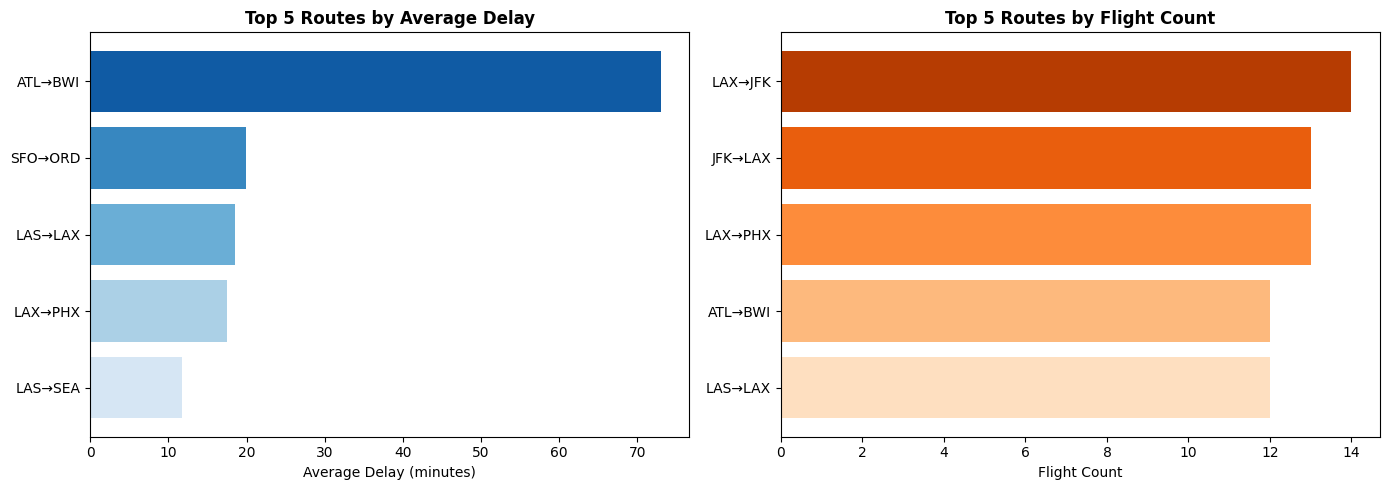

In [49]:
# plot degree and volume for top routes and airports
SIZE=5

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vol_plot = top_routes_delay.head(SIZE).copy()
vol_plot["route"] = vol_plot["origin"] + "→" + vol_plot["destination"]
axes[0].barh(vol_plot["route"][::-1], vol_plot["avg_delay"][::-1], color=sns.color_palette("Blues", SIZE))
axes[0].set_title(f"Top {SIZE} Routes by Average Delay", fontweight="bold")
axes[0].set_xlabel("Average Delay (minutes)")

hub_plot = top_routes_count.head(SIZE).copy()
hub_plot["route"] = hub_plot["origin"] + "→" + hub_plot["destination"]
axes[1].barh(hub_plot["route"][::-1], hub_plot["flights"][::-1], color=sns.color_palette("Oranges", SIZE))
axes[1].set_title(f"Top {SIZE} Routes by Flight Count", fontweight="bold")
axes[1].set_xlabel("Flight Count")

plt.tight_layout()
plt.show()

# Hub airports via simple in/out degree

In [50]:
# find top hub airport
# the degree is computed as the sum of 
# incoming  edges

run_query_df("""
MATCH (a:Airport)
OPTIONAL MATCH ()-[inn:ROUTE_TO]->(a)
WITH a, 
     count(inn) AS in_degree
RETURN a.iata AS iata,  in_degree
ORDER BY in_degree DESC
""").head()

,iata,in_degree
0,ATL,107
1,ORD,94
2,DFW,92
3,DEN,74
4,IAH,68


In [51]:
# find top hub airport
# the degree is computed as the sum of 
# outgoing  edges

airport_out_degree = run_query_df("""
MATCH (a:Airport)
OPTIONAL MATCH (a)-[out:ROUTE_TO]->()
WITH a, 
     count(out) AS out_degree
RETURN a.iata AS iata,
       out_degree
ORDER BY out_degree DESC
""")
airport_out_degree.head()

,iata,out_degree
0,ATL,108
1,ORD,96
2,DFW,87
3,DEN,80
4,IAH,66


# Using GDS plugin

In [52]:
# this is needed by the graph data science algorithms installed directly
# in our neo4j instance, but can be used as a general check for GDS presence and version.

gds_check = run_query_df("CALL gds.list() YIELD name RETURN count(name) AS n")
HAS_GDS = (not gds_check.empty) and int(gds_check.iloc[0]["n"]) > 0
assert HAS_GDS, "Graph Data Science library is not available in the Neo4j instance. Please install it to proceed with graph algorithms."


- Call the GDS (Graph Data Science) library procedure to project an in-memory graph using Cypher queries
    ```
    CALL gds.graph.project.cypher(
    ```

- Name the projected graph 'route_graph'


- define all nodes: match every Airport node and return its internal Neo4j ID as the node identifier
    ```
    'MATCH (a:Airport) RETURN id(a) AS id',
    ```

- Cypher query to define all relationships: match ROUTE_TO between airports, returning source node ID, target node ID, and flight count as weight (defaulting to 1.0 if null)
    ```
    'MATCH (a1:Airport)-[r:ROUTE_TO]->(a2:Airport) 
        RETURN id(a1) AS source, id(a2) AS target, coalesce(r.flights, 1.0) AS weight'
    ```

- Close the procedure call and yield the output variables containing graph metadata
    ```
    YIELD graphName, nodeCount, relationshipCount
    ```

In [53]:
run_query_df("CALL gds.graph.drop('route_graph', false) YIELD graphName")
run_query_df("CALL gds.graph.drop('airport_route_cypher', false) YIELD graphName")
# Check if graph exists, if not create it
graphs = run_query_df("CALL gds.graph.list() YIELD graphName RETURN graphName")
print(f"List of graphs {graphs.values}")


# Project the graph for GDS algorithms 
run_query_df("""
CALL gds.graph.project.cypher(
    'route_graph',
    'MATCH (a:Airport) RETURN id(a) AS id',
    'MATCH (a1:Airport)-[r:ROUTE_TO]->(a2:Airport) 
        RETURN id(a1) AS source, 
            id(a2) AS target, 
            coalesce(r.flights, 1.0) AS weight'
)
YIELD graphName, nodeCount, relationshipCount
RETURN graphName, nodeCount, relationshipCount
""")

Received notification from DBMS server: <GqlStatusObject gql_status='01N01', status_description='warn: feature deprecated with replacement. gds.graph.project.cypher is deprecated. It is replaced by gds.graph.project Cypher projection as an aggregation function.', position=<SummaryInputPosition line=2, column=1, offset=1>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 1, 'line': 2, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "\nCALL gds.graph.project.cypher(\n    'route_graph',\n    'MATCH (a:Airport) RETURN id(a) AS id',\n    'MATCH (a1:Airport)-[r:ROUTE_TO]->(a2:Airport) \n        RETURN id(a1) AS source, \n            id(a2) AS target, \n            coalesce(r.flights, 1.0) AS weight'\n)\nYIELD graphName, n

List of graphs [['route_scc_graph']
 ['airport_route_native']
 ['dijkstra_graph']]


,graphName,nodeCount,relationshipCount
0,route_graph,277,2164


# Connectivity analysis

## GLOBAL METRICS

- Diameter
- Effective Diameter
- Strongly Connected Components (SCC)
- Weakly Connected Components (WCC)

---

**Formula (Diameter):**

$$
\text{diam}(G) = \max_{(n,n') \in N \times N} \sigma(n, n')
$$

where:

- $\sigma(n, n')$ = shortest path between nodes $n$ and $n'$.

Interpretation:

- Effective diameter uses 90th percentile of pairwise distances (more robust).

Example:

- SCC: maximal set $C \subseteq V$ where every vertex reaches every other via directed paths.

In [54]:
# diameter 90th percentile (from top out airports for quick view)
top_airports = airport_out_degree.head(20)['iata'].tolist()

run_query_df("""
UNWIND $source_airports AS source_iata
MATCH (source:Airport {iata: source_iata})
CALL gds.allShortestPaths.delta.stream('route_graph', {
    sourceNode: id(source),
    delta: 1.0
})
YIELD targetNode, totalCost
WITH source_iata, totalCost AS distance  // Maintain source_iata here
WHERE distance IS NOT NULL AND distance < 1e9
RETURN source_iata AS source_airport, 
       percentileCont(distance, 0.90) AS d90p,
       max(distance) AS max_diameter,
       avg(distance) AS mean_distance
""", {'source_airports': top_airports})


Received notification from DBMS server: <GqlStatusObject gql_status='01N01', status_description='warn: feature deprecated with replacement. id is deprecated. It is replaced by elementId or consider using an application-generated id.', position=<SummaryInputPosition line=5, column=17, offset=155>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 155, 'line': 5, 'column': 17}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "\nUNWIND $source_airports AS source_iata\nMATCH (source:Airport {iata: source_iata})\nCALL gds.allShortestPaths.delta.stream('route_graph', {\n    sourceNode: id(source),\n    delta: 1.0\n})\nYIELD targetNode, totalCost\nWITH source_iata, totalCost AS distance  // Maintain source_iata here\nWHERE distance IS NO

,source_airport,d90p,max_diameter,mean_distance
0,ATL,2.0,3.0,1.556017
1,ORD,2.0,3.0,1.609959
2,DFW,2.0,3.0,1.639004
3,DEN,2.0,3.0,1.684647
4,IAH,2.0,3.0,1.742739
5,MSP,2.0,3.0,1.742739
6,LAX,2.0,3.0,1.771784
7,PHX,2.0,3.0,1.775934
8,DTW,2.0,3.0,1.879668
9,EWR,2.0,3.0,1.838174


In [55]:
run_query_df("""
UNWIND $source_airports AS source_iata
MATCH (source:Airport {iata: source_iata})
CALL gds.allShortestPaths.delta.stream('route_graph', {
    sourceNode: id(source),
    delta: 1.0
})
YIELD targetNode, totalCost
WITH totalCost AS distance
WHERE distance IS NOT NULL AND distance < 1e9
RETURN percentileCont(distance, 0.90) AS global_d90p,
       max(distance) AS max_diameter,
       avg(distance) AS mean_distance,
       count(distance) AS total_distances
""", {'source_airports': top_airports})

Received notification from DBMS server: <GqlStatusObject gql_status='01N01', status_description='warn: feature deprecated with replacement. id is deprecated. It is replaced by elementId or consider using an application-generated id.', position=<SummaryInputPosition line=5, column=17, offset=155>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 155, 'line': 5, 'column': 17}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "\nUNWIND $source_airports AS source_iata\nMATCH (source:Airport {iata: source_iata})\nCALL gds.allShortestPaths.delta.stream('route_graph', {\n    sourceNode: id(source),\n    delta: 1.0\n})\nYIELD targetNode, totalCost\nWITH totalCost AS distance\nWHERE distance IS NOT NULL AND distance < 1e9\nRETURN percentil

,global_d90p,max_diameter,mean_distance,total_distances
0,2.0,4.0,1.810996,4820


In [56]:
run_query_df("CALL gds.graph.drop('route_scc_graph', false) YIELD graphName")
# Check if graph exists, if not create it
graphs = run_query_df("CALL gds.graph.list() YIELD graphName RETURN graphName")
print(f"List of graphs {graphs.values}")



# Project the graph for CC algorithms 
run_query_df("""
    CALL gds.graph.project.cypher(
        'route_scc_graph',
        'MATCH (a:Airport) RETURN id(a) AS id',
        'MATCH (a1:Airport)-[r:ROUTE_TO]->(a2:Airport) 
         RETURN id(a1) AS source, id(a2) AS target'
    )
    YIELD graphName, nodeCount, relationshipCount
    RETURN graphName, nodeCount, relationshipCount
""")

Received notification from DBMS server: <GqlStatusObject gql_status='01N01', status_description='warn: feature deprecated with replacement. gds.graph.project.cypher is deprecated. It is replaced by gds.graph.project Cypher projection as an aggregation function.', position=<SummaryInputPosition line=2, column=5, offset=5>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 5, 'line': 2, 'column': 5}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "\n    CALL gds.graph.project.cypher(\n        'route_scc_graph',\n        'MATCH (a:Airport) RETURN id(a) AS id',\n        'MATCH (a1:Airport)-[r:ROUTE_TO]->(a2:Airport) \n         RETURN id(a1) AS source, id(a2) AS target'\n    )\n    YIELD graphName, nodeCount, relationshipCount\n    RE

List of graphs [['route_graph']
 ['airport_route_native']
 ['dijkstra_graph']]


,graphName,nodeCount,relationshipCount
0,route_scc_graph,277,2164


# Weakly Connected Components (WCC) - undirected graph

teorically not possible

In [57]:
# Run WCC algorithm
wcc_detailed = run_query_df("""
CALL gds.wcc.stream('route_scc_graph')
YIELD nodeId, componentId
MATCH (a:Airport) WHERE id(a) = nodeId
RETURN componentId, 
       count(a) AS component_count,
       collect(a.iata) AS airports_sets
ORDER BY component_count DESC
""")


display(wcc_detailed)

Received notification from DBMS server: <GqlStatusObject gql_status='01N01', status_description='warn: feature deprecated with replacement. id is deprecated. It is replaced by elementId or consider using an application-generated id.', position=<SummaryInputPosition line=4, column=25, offset=90>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 90, 'line': 4, 'column': 25}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "\nCALL gds.wcc.stream('route_scc_graph')\nYIELD nodeId, componentId\nMATCH (a:Airport) WHERE id(a) = nodeId\nRETURN componentId, \n       count(a) AS component_count,\n       collect(a.iata) AS airports_sets\nORDER BY component_count DESC\n"


,componentId,component_count,airports_sets
0,0,273,"[ATL, SAV, DEN, MCO, IAH, SFO, DFW, CMH, MIA, ..."
1,106,2,"[PSG, WRG]"
2,228,2,"[CDV, YAK]"


In fact we have unusable results

# Strongly Connected Components (SCC)

In [58]:
# Run SCC algorithm
scc_detailed = run_query_df("""
CALL gds.scc.stream('route_scc_graph')
YIELD nodeId, componentId
MATCH (a:Airport) WHERE id(a) = nodeId
RETURN componentId, 
       count(a) AS component_size,
       collect(a.iata) AS airports_sets
ORDER BY component_size DESC
""")


display(scc_detailed.head(10))

Received notification from DBMS server: <GqlStatusObject gql_status='01N01', status_description='warn: feature deprecated with replacement. id is deprecated. It is replaced by elementId or consider using an application-generated id.', position=<SummaryInputPosition line=4, column=25, offset=90>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 90, 'line': 4, 'column': 25}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "\nCALL gds.scc.stream('route_scc_graph')\nYIELD nodeId, componentId\nMATCH (a:Airport) WHERE id(a) = nodeId\nRETURN componentId, \n       count(a) AS component_size,\n       collect(a.iata) AS airports_sets\nORDER BY component_size DESC\n"


,componentId,component_size,airports_sets
0,0,205,"[ATL, SAV, DEN, MCO, IAH, SFO, DFW, CMH, MIA, ..."
1,106,2,"[PSG, WRG]"
2,230,2,"[HIB, INL]"
3,12,1,[FSM]
4,49,1,[AZO]
5,79,1,[RKS]
6,88,1,[BRW]
7,90,1,[HLN]
8,101,1,[COD]
9,102,1,[SIT]


In [59]:
# Build directed graph for comparison
def convert_nxgraph_to_df(centrality, k_desc, v_desc):
    return pd.DataFrame({
      k_desc: list(centrality.keys()),
      v_desc: list(centrality.values())
      }).sort_values(v_desc, ascending=False)

G_nx = nx.DiGraph()

# Get all ROUTE_TO relationships
edges = run_query_df("""
MATCH (o:Airport)-[r:ROUTE_TO]->(d:Airport)
RETURN o.iata AS source, d.iata AS target, r.flights AS weight
""")

for _, row in edges.iterrows():
    G_nx.add_edge(row['source'], row['target'], weight=row['weight'])

# Calculate SCCs with NetworkX
nx_scc = list(nx.strongly_connected_components(G_nx))
nx_scc_sizes = [len(c) for c in nx_scc]
print("="*50)
print("\nNetworkX SCC Results NetworkX")

print(f"Number of SCCs: {len(nx_scc)}")
print(f"NX - Largest SCC size: {max(nx_scc_sizes)}")
print(f"Number of singletons: {sum(1 for s in nx_scc_sizes if s == 1)}")
print(f"Average component size: {np.mean(nx_scc_sizes):.2f}")
print(f"Total components: {len(nx_scc_sizes)}")

print("\nNetworkX SCC Results GDS")
gds_sizes = scc_detailed['component_size'].tolist()
print(f"GDS - Largest SCC size: {max(gds_sizes)}")
print(f"GDS - Total components: {len(gds_sizes)}")



NetworkX SCC Results NetworkX
Number of SCCs: 71
NX - Largest SCC size: 205
Number of singletons: 68
Average component size: 3.90
Total components: 71

NetworkX SCC Results GDS
GDS - Largest SCC size: 205
GDS - Total components: 71


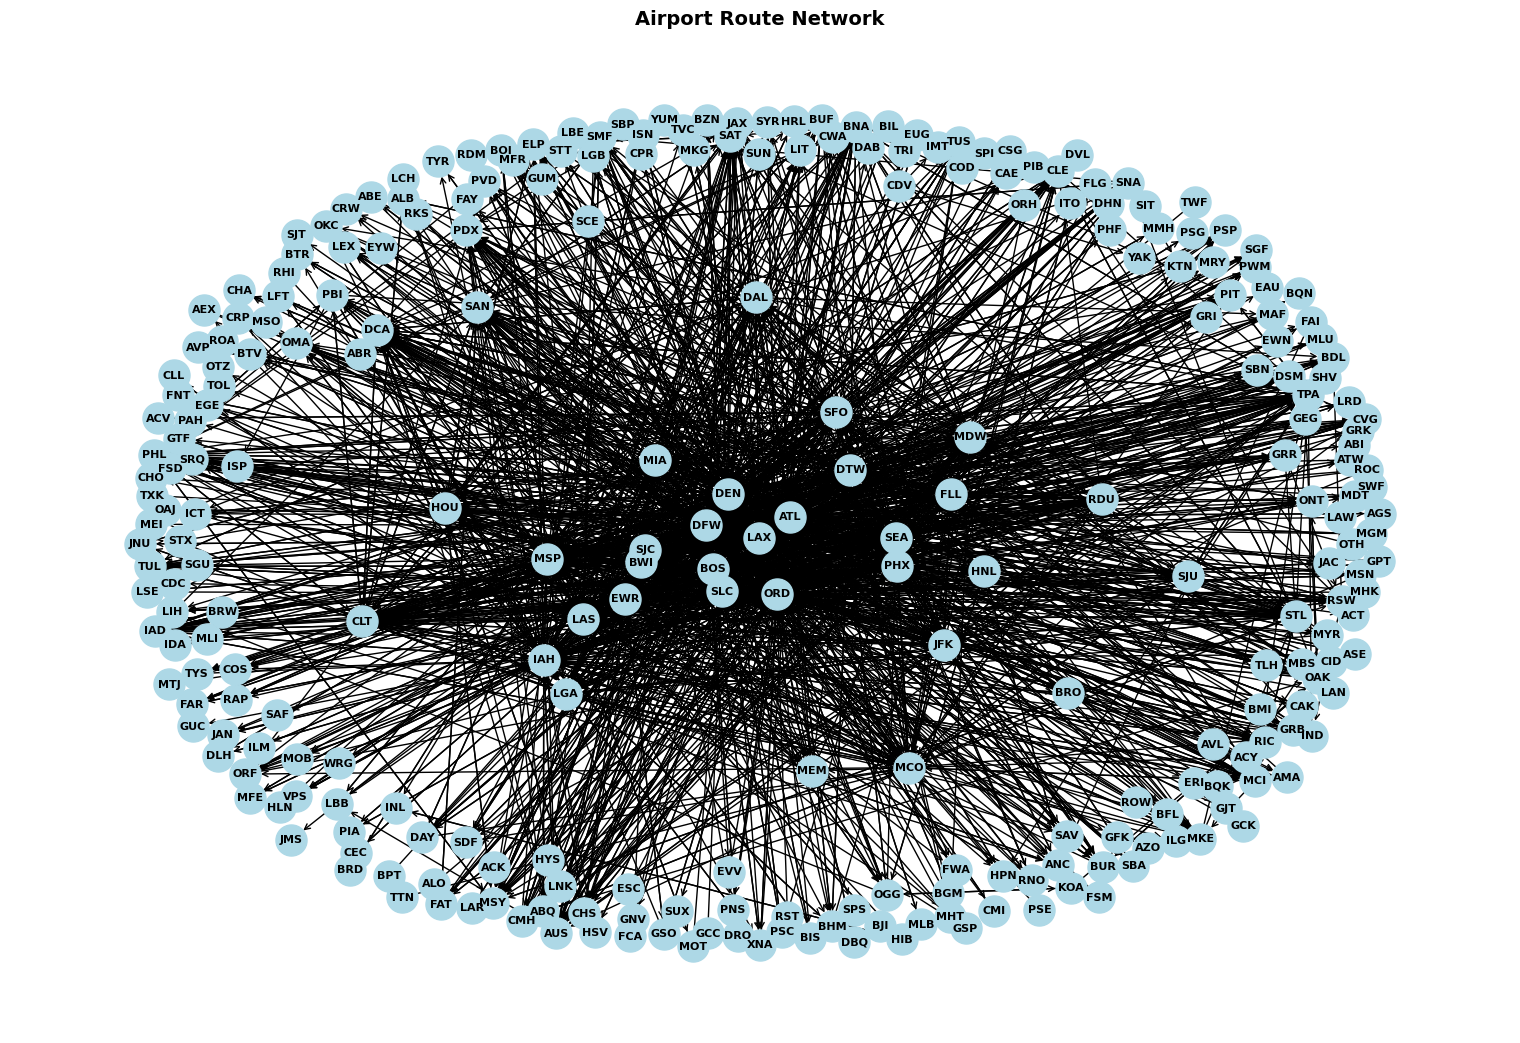

In [60]:
plt.figure(figsize=(15, 10))
pos = nx.spring_layout(G_nx, k=2, iterations=50)
nx.draw(G_nx, pos, with_labels=True, node_color='lightblue', 
        node_size=500, font_size=8, font_weight='bold',
        arrows=True, arrowstyle='->', arrowsize=10)
plt.title("Airport Route Network", fontweight='bold', fontsize=14)
# plt.tight_layout() # warning
plt.show()

In [61]:
Gu = G_nx.to_undirected()
triangles = nx.triangles(Gu)
triangles_df =  convert_nxgraph_to_df(triangles, "airports", "triangles")


clustering = nx.clustering(G_nx)
clustering_df =  convert_nxgraph_to_df(clustering, "airports", "clustering")



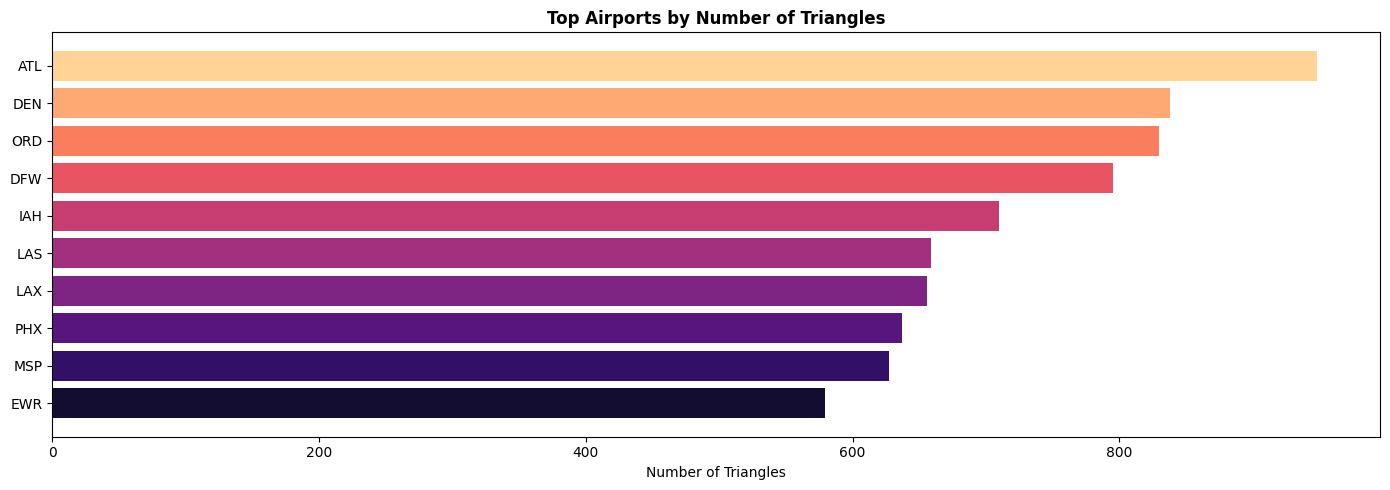

In [62]:


plt.subplots(1,1,figsize=(14, 5))

# Plot triangles (top 10 airports by triangle count)
plot_triangles = triangles_df.sort_values('triangles', ascending=False).head(10).copy()
plt.barh(plot_triangles["airports"][::-1], plot_triangles["triangles"][::-1],
         color=sns.color_palette("magma", len(plot_triangles)))
plt.title("Top Airports by Number of Triangles", fontweight="bold")
plt.xlabel("Number of Triangles")

plt.tight_layout()
plt.show()


# Centrality analysis

## METRICS

- Degree Centrality
- Freeman's Network Centrality






**Formula (Degree Centrality):**

$$
C_D(v) = \frac{\text{deg}(v)}{|V|-1}
$$


In [63]:
G=G_nx.copy()


In [64]:
in_degree_centrality = nx.in_degree_centrality(G)
display(convert_nxgraph_to_df(in_degree_centrality, 'airport', 'in_degree_centrality').head())

,airport,in_degree_centrality
0,ATL,0.387681
85,ORD,0.340580
90,DFW,0.333333
15,DEN,0.268116
6,IAH,0.246377


In [65]:
out_degree_centrality = nx.out_degree_centrality(G)
display(convert_nxgraph_to_df(out_degree_centrality, 'airport', 'out_degree_centrality').head())

,airport,out_degree_centrality
0,ATL,0.391304
85,ORD,0.347826
90,DFW,0.315217
15,DEN,0.289855
6,IAH,0.239130


In [66]:
# normalized 
degree_centrality = nx.degree_centrality(G, )  # For undirected
display(convert_nxgraph_to_df(degree_centrality, 'airport', 'degree_centrality').head())

,airport,degree_centrality
0,ATL,0.778986
85,ORD,0.688406
90,DFW,0.648551
15,DEN,0.557971
6,IAH,0.485507


In [67]:
# Degree centrality with GDS
degree_centrality_not_norm = run_query_df("""
CALL gds.degree.stream('route_scc_graph')
YIELD nodeId, score
RETURN gds.util.asNode(nodeId).iata AS airport, 
       score AS degree_centrality
ORDER BY degree_centrality DESC
LIMIT 5
""")
degree_centrality_not_norm


,airport,degree_centrality
0,ATL,108.0
1,ORD,96.0
2,DFW,87.0
3,DEN,80.0
4,IAH,66.0


**Formula (Freeman's Network Centrality):**

$$
C_D = \frac{\sum_{i=1}^{|V|} [\text{deg}^*(v) - \text{deg}(i)]}{(|V|-1)(|V|-2)}
$$

Interpretation:

- Degree = immediate risk of catching information or virus.
- Star network maximizes degree centrality.

Example:

- BrandWatch identifies influential people on Twitter (60M+ followers).

In [68]:

def freeman_network_centrality(G):
    """
    Calculate Freeman's degree centralization measure
    C_D = sum(deg_max - deg_i) / ((n-1)*(n-2))
    """
    n = G.number_of_nodes()
    degrees = [d for n, d in G.degree()]
    deg_max = max(degrees)
    
    sum_diff = sum(deg_max - deg for deg in degrees)
    centralization = sum_diff / ((n - 1) * (n - 2))
    
    return centralization

# Calculate for your graph
centralization_score = freeman_network_centrality(Gu)  # Use undirected
print(f"Freeman's Network Centrality: {centralization_score:.6f}")
print(f"Interpretation: {'Star-like' if centralization_score > 0.5 else 'Decentralized'}")

Freeman's Network Centrality: 0.414308
Interpretation: Decentralized



## METRICS

- Betweenness Centrality
- Closeness Centrality
- PageRank


**Formula (Betweenness Centrality):**

$$
C_B(v) = \sum_{j \neq k} \frac{g_{jk}(v)}{g_{jk}}
$$

**Normalized:**

$$
C_B'(v) = \frac{2 C_B(v)}{(|V|-1)(|V|-2)}
$$

where:

- $g_{jk}(v)$ = number of shortest paths between $j$ and $k$ passing through $v$
- $g_{jk}$ = total number of shortest paths

Interpretation:

- High betweenness = choke-point for information flow.
- Failure of such nodes is problematic.

Example:

- Telecommunications network analysis.
- Identifying influencers in criminal organizations.


In [69]:
# Betweenness centrality (can be slow for large graphs)
# For directed graph
betweenness = nx.betweenness_centrality(G, normalized=True)
display(convert_nxgraph_to_df(betweenness, 'airport', 'betweenness').head())

,airport,betweenness
0,ATL,0.179989
85,ORD,0.149436
90,DFW,0.136175
15,DEN,0.089639
6,IAH,0.072728


In [70]:
betweenness_undirected = nx.betweenness_centrality(Gu, normalized=True)
display(convert_nxgraph_to_df(betweenness_undirected, 'airport', 'betweenness').head())

,airport,betweenness
85,ORD,0.194102
0,ATL,0.189536
90,DFW,0.188450
15,DEN,0.132571
11,MSP,0.098620


In [71]:
# directed
run_query_df("""
CALL gds.betweenness.stream('route_scc_graph')
YIELD nodeId, score
RETURN gds.util.asNode(nodeId).iata AS airport, 
       score AS betweenness_centrality
ORDER BY betweenness_centrality DESC
LIMIT 5
""")

,airport,betweenness_centrality
0,ATL,13661.169064
1,ORD,11342.215647
2,DFW,10335.703311
3,DEN,6803.578211
4,IAH,5520.017722


**Formula (Closeness Centrality):**

$$
CC(v) = \left( \sum_{i=1}^{|V|} \sigma(v, i) \right)^{-1}
$$

**Normalized:**

$$
CC'(v) = \frac{|V|-1}{\sum_{i=1}^{|V|} \sigma(v, i)}
$$

Interpretation:

- Based on average shortest path length to all vertices.
- Desires proximity to network center.

In [72]:
closeness = nx.closeness_centrality(G)
display(convert_nxgraph_to_df(closeness, 'airport', 'closeness').head())

,airport,closeness
0,ATL,0.541011
85,ORD,0.529651
90,DFW,0.528265
15,DEN,0.500737
6,IAH,0.495816


In [73]:
# For undirected (if graph is not strongly connected)
closeness_undirected = nx.closeness_centrality(Gu)
display(convert_nxgraph_to_df(closeness, 'airport', 'closeness').head())


,airport,closeness
0,ATL,0.541011
85,ORD,0.529651
90,DFW,0.528265
15,DEN,0.500737
6,IAH,0.495816


**Formula (PageRank):**

$$
p(d_i) = (1-\alpha) \sum_{d_j \in IN(d_i)} m_{ji} p(d_j) + \alpha \frac{1}{N}
$$

where:

- $m_{ji} = 1/\text{OUT}(d_j)$ (transition probability)
- $\alpha$ = random jump probability

Interpretation:

- Random surfer model: with probability $\alpha$ jumps randomly, with probability $(1-\alpha)$ follows a link.
- Captures Web page popularity via indirect citations.

Example:

- Google's original search engine ranking algorithm.

In [74]:
# PageRank (GDS) 

pagerank = run_query_df("""
CALL gds.pageRank.stream('route_graph',
    {relationshipWeightProperty: 'weight', maxIterations: 50, dampingFactor: 0.85})
YIELD nodeId, score
RETURN gds.util.asNode(nodeId).iata AS airport,
        score AS pr_score
ORDER BY pr_score DESC
""")

display(pagerank.head())

,airport,pr_score
0,ATL,15.681014
1,ORD,11.716968
2,DFW,10.054986
3,DEN,7.745882
4,IAH,6.518831


Interpretation hint:

Airports appearing on top of all rankings have strong structural fights routes.


# Community analysis

## COMMUNITY STRUCTURE METRICS

- Modularity ($Q$)
- Edge betweenness
  - Girvan-Newman
  - Louvain

---

**Formula (Modularity):**

$$
Q = \sum_i (e_{ii} - a_i^2)
$$

where:

- $e_{ii}$ = percentage of edges within community $i$
- $a_i = \sum_j e_{ij}$ = percentage of edges incident to community $i$

Interpretation:

- $Q \in [-1, 1]$; $0.3 < Q < 0.7$ indicates significant community structure.
- Compares actual edges within communities vs. expected edges in random graph.

Example:

- Karate club dataset yields $Q = 0.381$ for optimal partition.


In [75]:
communities_louvain = list(louvain_communities(G, seed=42))
modularity(Gu, communities_louvain)

0.2707354954102147


**Algorithm (Girvan-Newman Edge Betweenness):**

| Step | Operation |
| :--- | :--- |
| 1. | Calculate edge betweenness for all edges |
| 2. | Remove edge with highest betweenness score |
| 3. | Recalculate betweenness for affected edges |
| 4. | Go to 2 until no edges remain |

Interpretation:

- $O(m^2n)$ complexity; smaller on graphs with strong clustering.
- Produces dendrogram; cut at highest modularity.


In [76]:
MAX_LEVELS = 5

# for dendrogram?

# Run Girvan-Newman
communities_generator = girvan_newman(G)

# Simple statistics
print("Girvan-Newman Community Detection")
print("="*40)

for i, communities in enumerate(communities_generator):
    if i >= MAX_LEVELS:  # Show first 5 levels only
        print(f"\n... stopping after {i} levels")
        break
    
    comm_list = list(communities)
    sizes = [len(c) for c in comm_list]
    
    print(f"\nLevel {i+1}:")
    print(f"  Communities: {len(comm_list)}")
    print(f"  Sizes: {sizes}")
    print(f"  Min size: {min(sizes)}")
    print(f"  Max size: {max(sizes)}")
    print(f"  Avg size: {sum(sizes)/len(sizes):.1f}")

Girvan-Newman Community Detection



Level 1:
  Communities: 4
  Sizes: [271, 2, 2, 2]
  Min size: 2
  Max size: 271
  Avg size: 69.2

Level 2:
  Communities: 5
  Sizes: [268, 2, 3, 2, 2]
  Min size: 2
  Max size: 268
  Avg size: 55.4

Level 3:
  Communities: 6
  Sizes: [267, 1, 2, 3, 2, 2]
  Min size: 1
  Max size: 267
  Avg size: 46.2

Level 4:
  Communities: 7
  Sizes: [266, 1, 1, 2, 3, 2, 2]
  Min size: 1
  Max size: 266
  Avg size: 39.6

Level 5:
  Communities: 8
  Sizes: [265, 1, 1, 1, 2, 3, 2, 2]
  Min size: 1
  Max size: 265
  Avg size: 34.6

... stopping after 5 levels



**Algorithm (Louvain):**

| Step | Operation |
| :--- | :--- |
| 1. | Assign different community to each node |
| 2. | For each node $i$, evaluate modularity gain by moving to neighbor $j$'s community |
| 3. | Repeat sequentially until no further improvement |
| 4. | Aggregate communities into super-nodes |


Repeat passes until no further modularity increase.

Interpretation:

- Fast greedy algorithm for networks with millions of nodes.
- Local maxima of modularity attained per phase.

In [77]:
communities = list(louvain_communities(G, seed=42))
print("Louvain Community Detection")
print("="*40)
sizes = [len(c) for c in communities]
print(f"Communities: {len(communities)}")
print(f"Sizes: {sizes}")

Louvain Community Detection
Communities: 6
Sizes: [97, 79, 50, 47, 2, 2]


In [78]:
run_query_df("CALL gds.graph.drop('airport_route_native', false) YIELD graphName")
# Check if graph exists, if not create it
graphs = run_query_df("CALL gds.graph.list() YIELD graphName RETURN graphName")
print(f"List of graphs {graphs.values}")


#  Build projection for community and path analysis 

run_query_df("CALL gds.graph.drop('airport_route_native', false) YIELD graphName")
run_query_df("""
CALL gds.graph.project(
  'airport_route_native',
  'Airport',
  {ROUTE_TO: {orientation: 'NATURAL', properties: ['flights', 'avg_delay']}}
)
YIELD graphName, nodeCount, relationshipCount
RETURN graphName, nodeCount, relationshipCount
""")


List of graphs [['route_graph']
 ['route_scc_graph']
 ['dijkstra_graph']]


,graphName,nodeCount,relationshipCount
0,airport_route_native,277,2164


In [79]:
# Community detection 

communities = run_query_df("""
CALL gds.louvain.stream('airport_route_native', {relationshipWeightProperty: 'flights'})
YIELD nodeId, communityId
RETURN gds.util.asNode(nodeId).iata AS iata,
        gds.util.asNode(nodeId).state AS state,
        communityId
ORDER BY communityId, iata
""")


community_sizes = (
    communities.groupby("communityId", dropna=False)
    .size()
    .reset_index(name="airports")
    .sort_values("airports", ascending=False)
    .head()
)
display(community_sizes)

,communityId,airports
7,276,77
4,272,76
1,266,60
5,273,57
3,269,2


- interpretation hint:

Large communities indicate dense operational clusters; high-delay routes and
critical shortest-delay paths identify bottlenecks and intervention priorities.

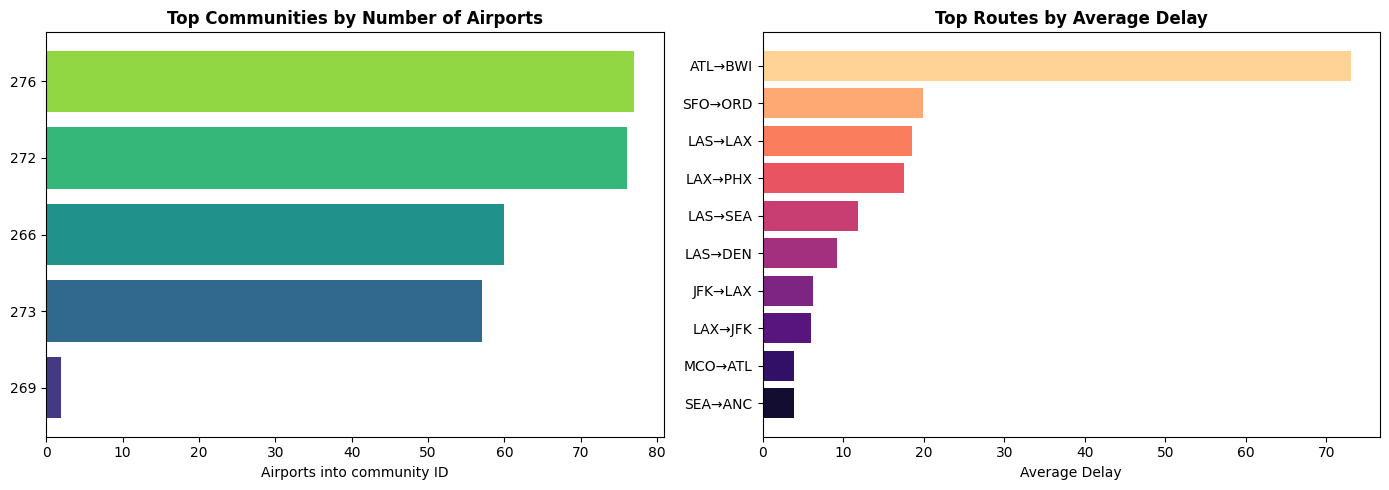

In [80]:
# visual summary and interpretation support
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_cs = community_sizes.head(10).copy()
axes[0].barh(plot_cs["communityId"].astype(str)[::-1], plot_cs["airports"][::-1],
             color=sns.color_palette("viridis", len(plot_cs)))
axes[0].set_title("Top Communities by Number of Airports", fontweight="bold")
axes[0].set_xlabel("Airports into community ID")

delay_plot = top_routes_delay.head(10).copy()
delay_plot["route"] = delay_plot["origin"] + "→" + delay_plot["destination"]
axes[1].barh(delay_plot["route"][::-1], delay_plot["avg_delay"][::-1],
             color=sns.color_palette("magma", len(delay_plot)))
axes[1].set_title("Top Routes by Average Delay", fontweight="bold")
axes[1].set_xlabel("Average Delay")

plt.tight_layout()
plt.show()




# Path analysis

## ALGORITHMS

- Single Source Shortest Path (SSSP)
- All Pairs Shortest Path (APSP)
- Minimum Weight Spanning Tree (MST)


In [81]:
low_rank_airport = run_query_df("""
MATCH (a:Airport)
OPTIONAL MATCH (a)-[r:ROUTE_TO]->()
WITH a, count(r) AS degree
WHERE degree > 0 AND degree < 10  // Low degree airport
RETURN a.iata AS airport, degree
ORDER BY degree ASC
LIMIT 1
""")
source_airport = low_rank_airport.iloc[0]['airport']
print(f"Selected low-rank airport: {source_airport}")

# not directly connected
destination_airport = run_query_df(f"""
MATCH (source:Airport {{iata: '{source_airport}'}})
MATCH (dest:Airport)
WHERE NOT EXISTS((source)-[:ROUTE_TO]->(dest))
  AND source.iata <> dest.iata
RETURN dest.iata AS airport, dest.city AS city
LIMIT 1
""")

dest_airport = destination_airport.iloc[0]['airport']
print(f"Destination airport (not directly connected): {dest_airport}")

edges = run_query_df("""
MATCH (o:Airport)-[r:ROUTE_TO]->(d:Airport)
RETURN o.iata AS source, d.iata AS target, r.flights AS weight
""")

G_weighted = nx.DiGraph()
for _, row in edges.iterrows():
    G_weighted.add_edge(row['source'], row['target'], weight=row['weight'])

Selected low-rank airport: FSM
Destination airport (not directly connected): ABE




**Algorithm (Dijkstra's SSSP):**

Interpretation:

- Greedy approach for weighted graphs with non-negative edge weights.
- Outputs shortest path lengths from source $s$ to all vertices.

Example:

- Open Shortest Path First (OSPF) routing protocol for IP networks.



In [82]:
path = nx.dijkstra_path(G_weighted, source_airport, dest_airport, weight='weight')
path

['FSM', 'DFW', 'SGF', 'ATL', 'ABE']

In [83]:
path_length = nx.dijkstra_path_length(G_weighted, source_airport, dest_airport, weight='weight')
path_length

7

In [84]:
run_query_df("CALL gds.graph.drop('dijkstra_graph', false) YIELD graphName")
# Check if graph exists, if not create it
graphs = run_query_df("CALL gds.graph.list() YIELD graphName RETURN graphName")
print(f"List of graphs {graphs.values}")
run_query("""
CALL gds.graph.project.cypher(
    'dijkstra_graph',
    'MATCH (a:Airport) RETURN id(a) AS id',
    'MATCH (a1:Airport)-[r:ROUTE_TO]->(a2:Airport) 
     RETURN id(a1) AS source, id(a2) AS target, r.flights AS weight'
)
YIELD graphName, nodeCount, relationshipCount
RETURN graphName, nodeCount, relationshipCount
""")
result = run_query_df(f"""
MATCH (source:Airport {{iata: '{source_airport}'}})
MATCH (dest:Airport {{iata: '{dest_airport}'}})
CALL gds.shortestPath.dijkstra.stream('dijkstra_graph', {{
    sourceNode: id(source),
    targetNode: id(dest),
    relationshipWeightProperty: 'weight'
}})
YIELD index, sourceNode, targetNode, totalCost, nodeIds, costs, path
RETURN [node in nodeIds | gds.util.asNode(node).iata] AS shortestPath,
       totalCost AS pathWeight
""")
display(result)



Received notification from DBMS server: <GqlStatusObject gql_status='01N01', status_description='warn: feature deprecated with replacement. gds.graph.project.cypher is deprecated. It is replaced by gds.graph.project Cypher projection as an aggregation function.', position=<SummaryInputPosition line=2, column=1, offset=1>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 1, 'line': 2, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "\nCALL gds.graph.project.cypher(\n    'dijkstra_graph',\n    'MATCH (a:Airport) RETURN id(a) AS id',\n    'MATCH (a1:Airport)-[r:ROUTE_TO]->(a2:Airport) \n     RETURN id(a1) AS source, id(a2) AS target, r.flights AS weight'\n)\nYIELD graphName, nodeCount, relationshipCount\nRETURN graphNa

List of graphs [['route_graph']
 ['route_scc_graph']
 ['airport_route_native']]


,shortestPath,pathWeight
0,"[FSM, DFW, MSN, ATL, ABE]",7.0



**Definition (Minimum Weight Spanning Tree):**

$$
W(T) = \sum_{e \in T} W(e)
$$

$$
\text{MST} = \underset{T}{\operatorname{argmin}} \; W(T)
$$

where:

- $T$ is a spanning tree with $|V|-1$ edges connecting all vertices.

Interpretation:

- Prim's algorithm is a classic MST algorithm.

Example:

- Design low-cost tours visiting many destinations.
- Trace infection transmission in outbreak epidemiology.


In [85]:
route_edges_df = run_query_df("""
MATCH (o:Airport)-[r:ROUTE_TO]->(d:Airport)
RETURN o.iata AS source,
       d.iata AS target,
       coalesce(r.flights, 1.0) AS flights,
       coalesce(r.avg_delay, 0.0) AS avg_delay
""")

Gd = nx.DiGraph()
for _, row in route_edges_df.iterrows():
    Gd.add_edge(
        row['source'],
        row['target'],
        flights=float(row['flights']),
        avg_delay=float(row['avg_delay']),
    )

# nonsense for undirected, as example only
Gu = Gd.to_undirected()
wcc = list(nx.connected_components(Gu))
largest_wcc = max(wcc, key=len)
Gu_wcc = Gu.subgraph(largest_wcc).copy()

mst_delay = nx.minimum_spanning_tree(Gu, weight="delay_cost")

print(f"Edges: {mst_delay.number_of_edges()}")
print(f"Nodes reached: {mst_delay.number_of_nodes()}")


Edges: 274
Nodes reached: 277


In [86]:
driver.close()

# Data interpretation (of a representative salmpe of 5000 records)

## Final Conclusions

### Which airports are the most critical for connectivity and potential disruption propagation in the US flight network?

The analysis consistently identifies **ATL, ORD, DFW, DEN, and IAH** as the most critical airports.  
They rank at the top across **degree**, **betweenness**, **closeness**, and **PageRank**, meaning they are simultaneously:
1. highly connected,
2. frequently traversed as transfer points,
3. close to most other airports,
4. structurally influential in traffic flow.

This convergence across centrality metrics indicates that disruptions at these hubs can propagate widely and quickly through the network.  
At the same time, the Freeman centralization score (~**0.414**) suggests the network is **hub-dominated but not purely star-shaped**, so resilience exists but remains strongly dependent on a small set of core airports.

### How do community structure and weighted shortest paths reveal operational clusters and efficient/critical routes between airports?

Community detection shows a clear meso-structure: **Louvain communities** (largest sizes around **97, 79, 50, 47**) with modularity around **0.271**, indicating meaningful but not fully isolated clusters.  
This suggests the US network is organized into operational groups with substantial inter-community connectivity.

Weighted shortest-path analysis confirms that routes between less central airports are often mediated by major hubs (example: **FSM → DFW → SGF → ATL → ABE**, total cost **7** in the chosen weight model).  

